In [415]:
import matplotlib.pyplot as plt
import numpy as np
import random
import scipy
import skimage

from lamina.loading.album import Album
from PIL import Image

In [416]:
album = Album(
    format=["png", "bmp", "tif"],
    image_store=r"/mnt/myshare/Hubby/School/Grad/Research/Borys/Data/Optical_Microscopy"
)

In [417]:
album.make_album()

Could not open /mnt/myshare/Hubby/School/Grad/Research/Borys/Data/Optical_Microscopy/Michael Popcorn AFM/20191012 1 2/Pop 3.bmp.


In [418]:
photos = album.photos

### Where the fun begins

In [419]:
random_image = random.choice(sum([list(photos[_].values()) for _ in photos.keys()], start=list([])))

In [420]:
random_image.filename

'/mnt/myshare/Hubby/School/Grad/Research/Borys/Data/Optical_Microscopy/190726,1/ROI3, 60x oil, maybe something.png'

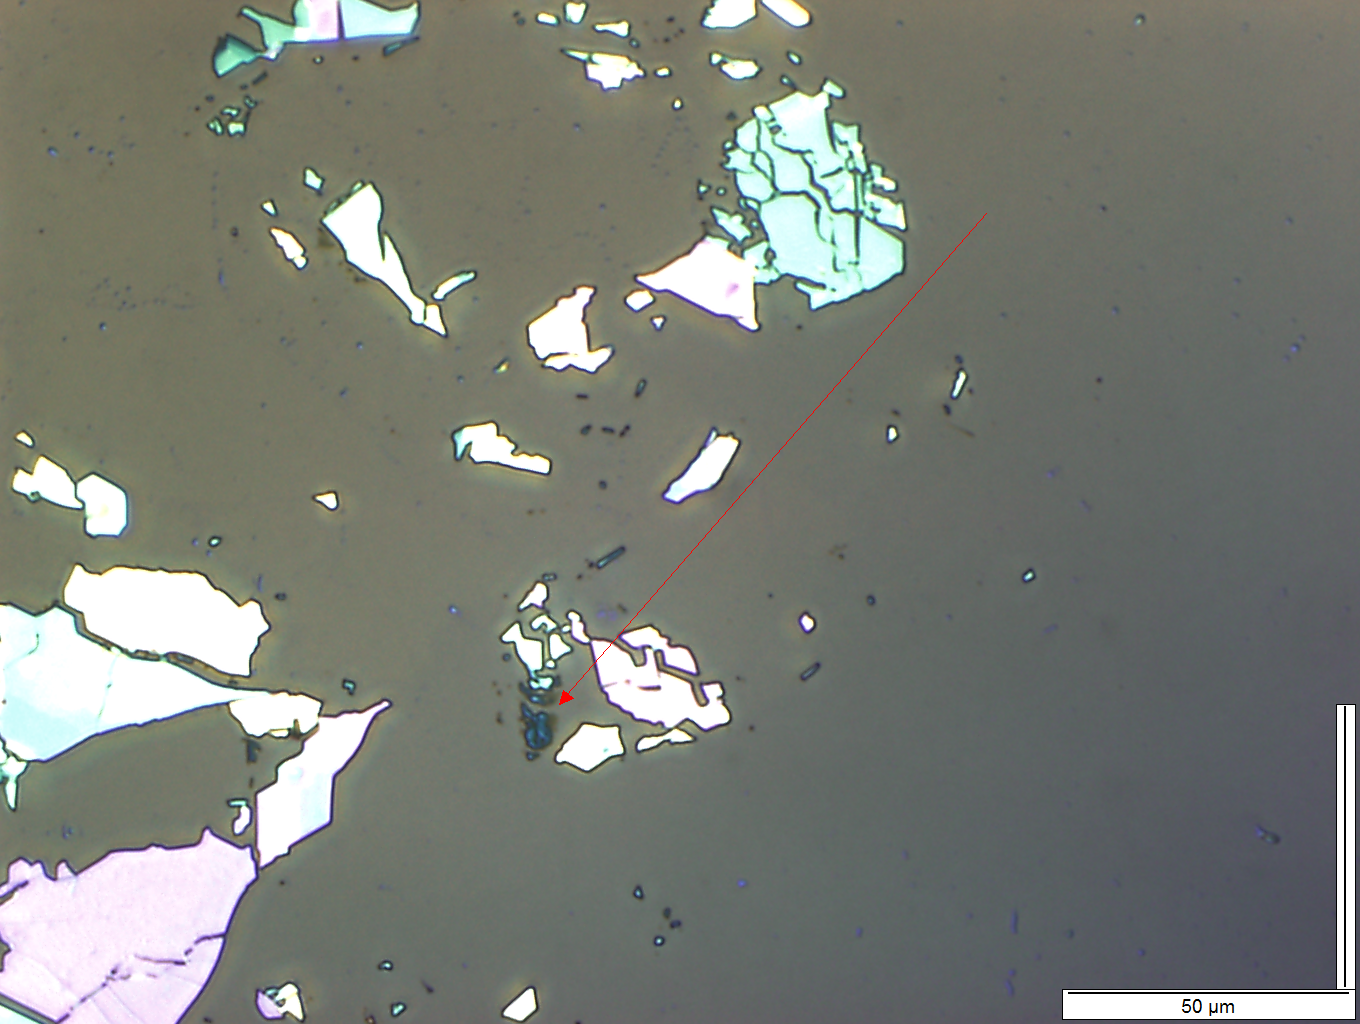

In [421]:
random_image

In [422]:
random_image_array = np.array(random_image)

### Masking all pixels that are in the labels and arrows

In [423]:
max_8_bit = 2 ** 8 - 1
min_8_bit = 0

black = [min_8_bit, min_8_bit, min_8_bit]
white = [max_8_bit, max_8_bit, max_8_bit]
red = [max_8_bit, min_8_bit, min_8_bit]
blue = [min_8_bit, min_8_bit, max_8_bit]

# Making the image mask.
mask_image = np.array(random_image)

# Checking for the colors we want to ignore in the original image.
black_mask = np.all(mask_image == black, axis=2)
white_mask = np.all(mask_image == white, axis=2)
red_mask = np.all(mask_image == red, axis=2)
blue_mask = np.all(mask_image == blue, axis=2)

label_mask = black_mask | white_mask | red_mask | blue_mask

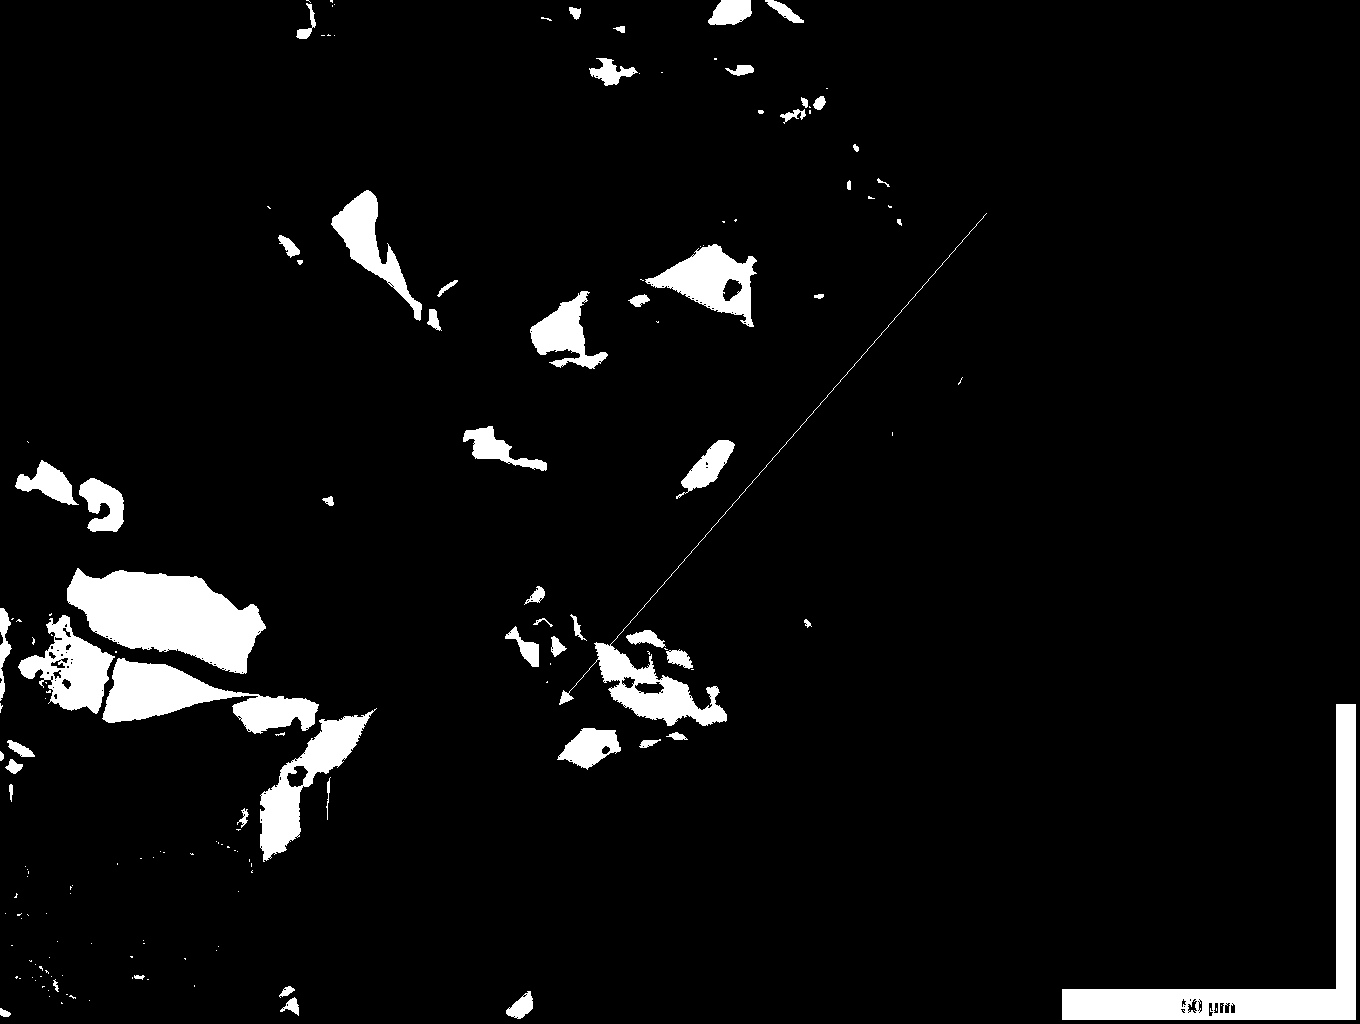

In [424]:
label_mask_image = Image.fromarray(label_mask)
label_mask_image

### Changing image to grayscale for easier thresholding

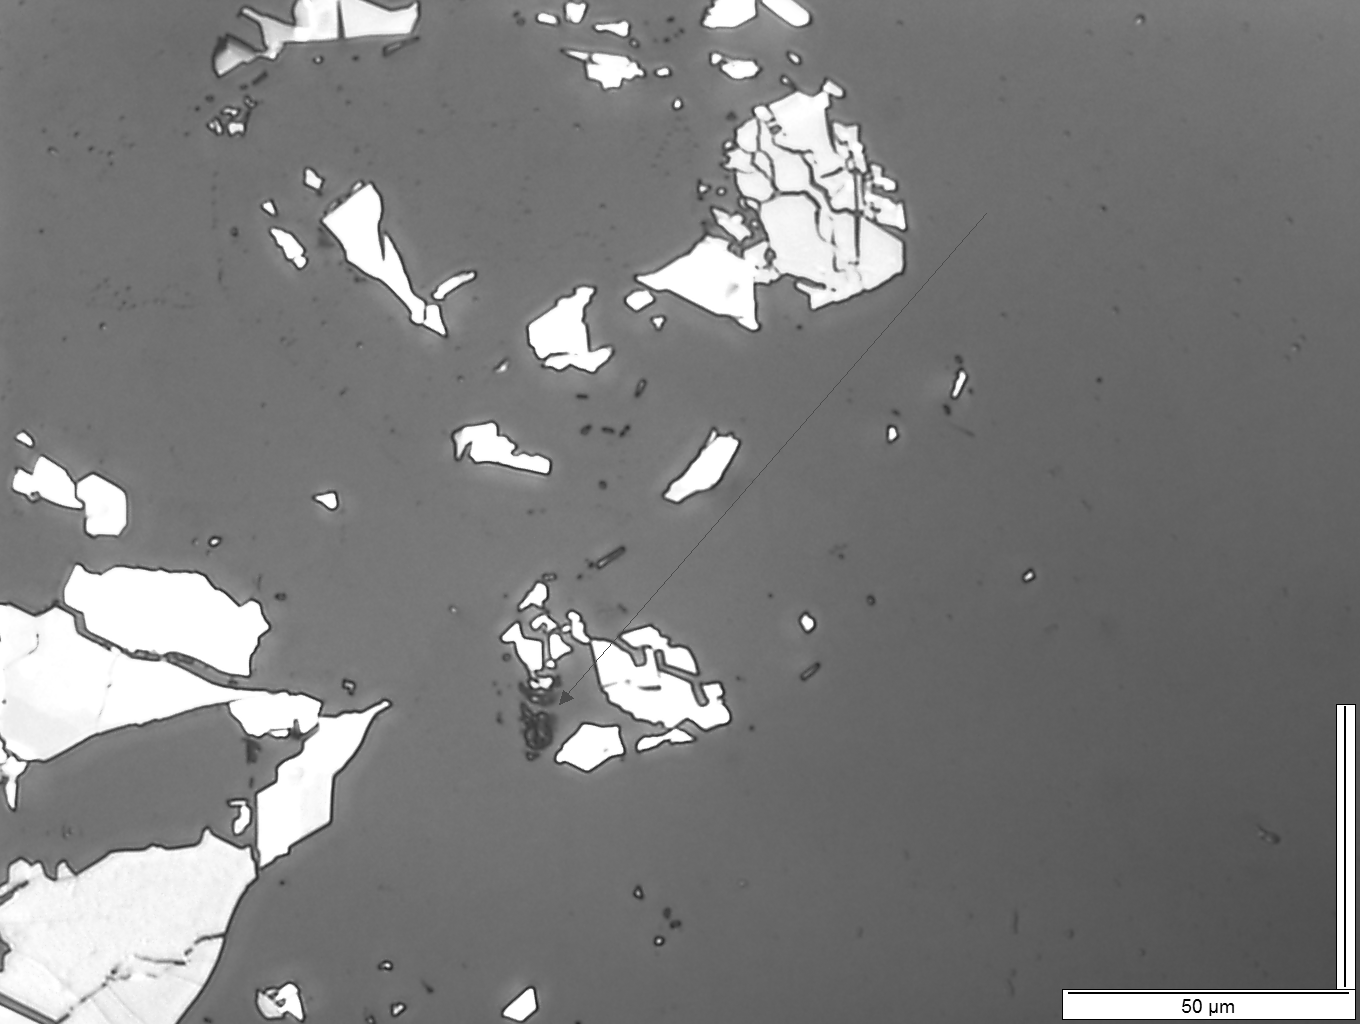

In [425]:
grayscale_image = random_image.convert("L")
grayscale_image

In [426]:
grayscale = np.array(grayscale_image)

### Testing out a Butterworth filter.

## Setting labels to image background # In the analysis, this part will only be used if the Canny Edge Filter fails.

### Setting background to max background value to flatten the background

In [427]:
# f, axs = plt.subplots()

# bins = np.arange(0,256)
# counts = axs.hist(grayscale.flatten(), bins=bins)[0]
# max_background_where = np.where(counts == max(counts))
# max_background_bin = bins[max_background_where]

# grad = np.gradient(counts[1:-1])
# max_grad_where = np.where(grad == max(grad))
# first_index = bins[max_grad_where][0]
# min_grad_where = np.where(grad == min(grad))
# second_index = bins[min_grad_where][0]

# axs.vlines(first_index, min(counts), max(counts), color="black", linestyles='dashed')
# axs.vlines(second_index, min(counts), max(counts), color="black", linestyles='dashed')
# axs.plot()

####  Flattening the background

In [428]:
# flatten_background_mask = (grayscale >= first_index) & (grayscale <= second_index)
# grayscale[flatten_background_mask] = max_background_bin

#### Setting the labels to the background 

In [429]:
# grayscale[label_mask] = max_background_bin

In [430]:
# _ = Image.fromarray(grayscale)
# _

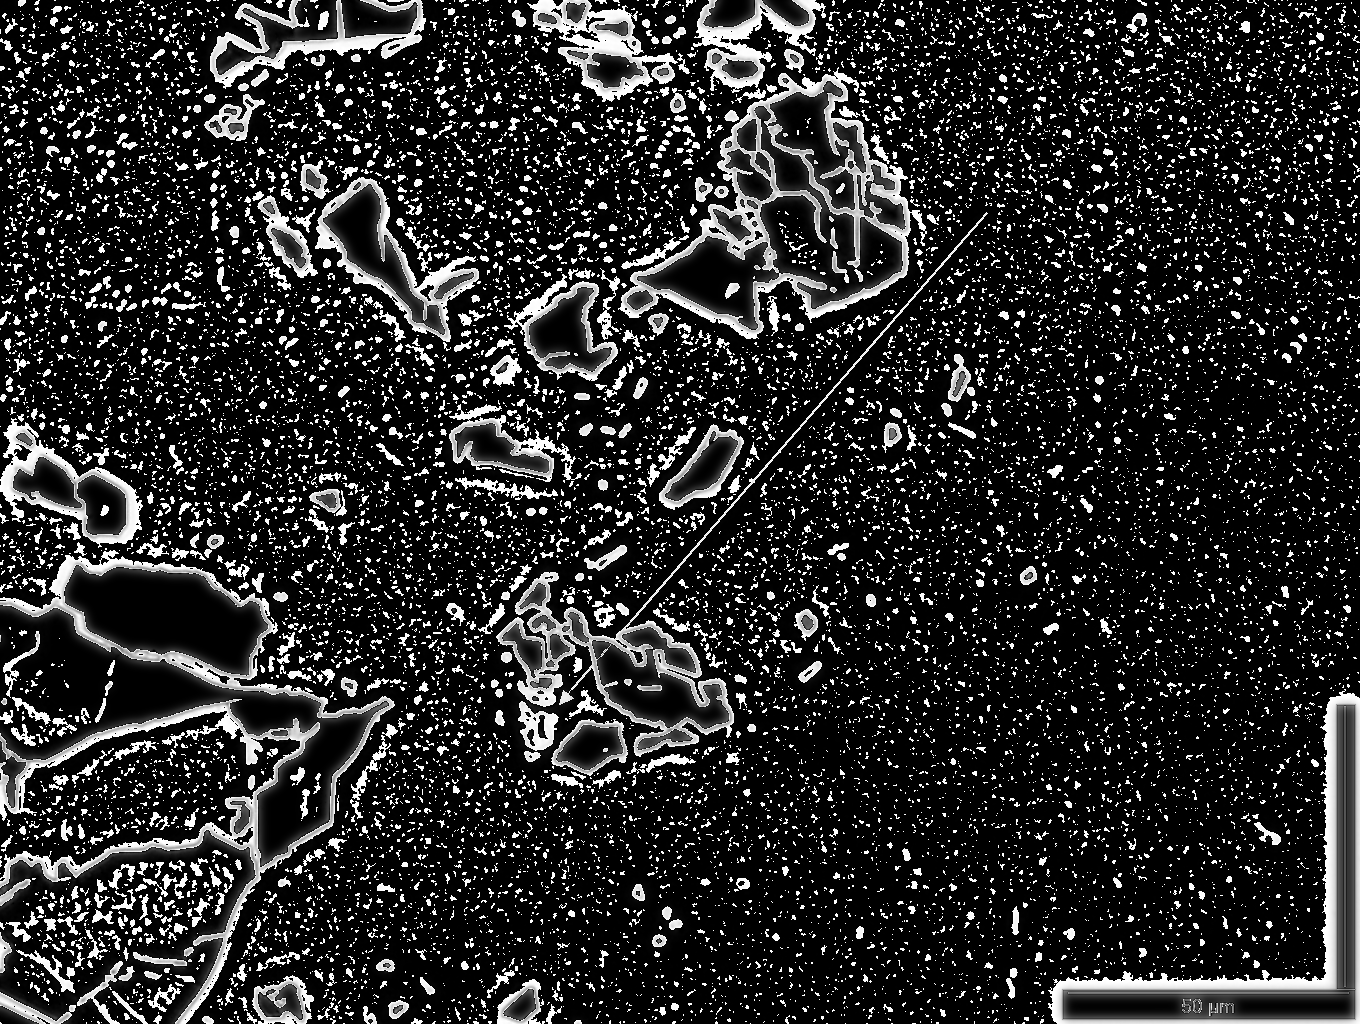

In [431]:
dog = skimage.filters.difference_of_gaussians(grayscale, 0.5, 5)
dog_image = Image.fromarray((dog * 255).astype(np.uint8))
dog_image

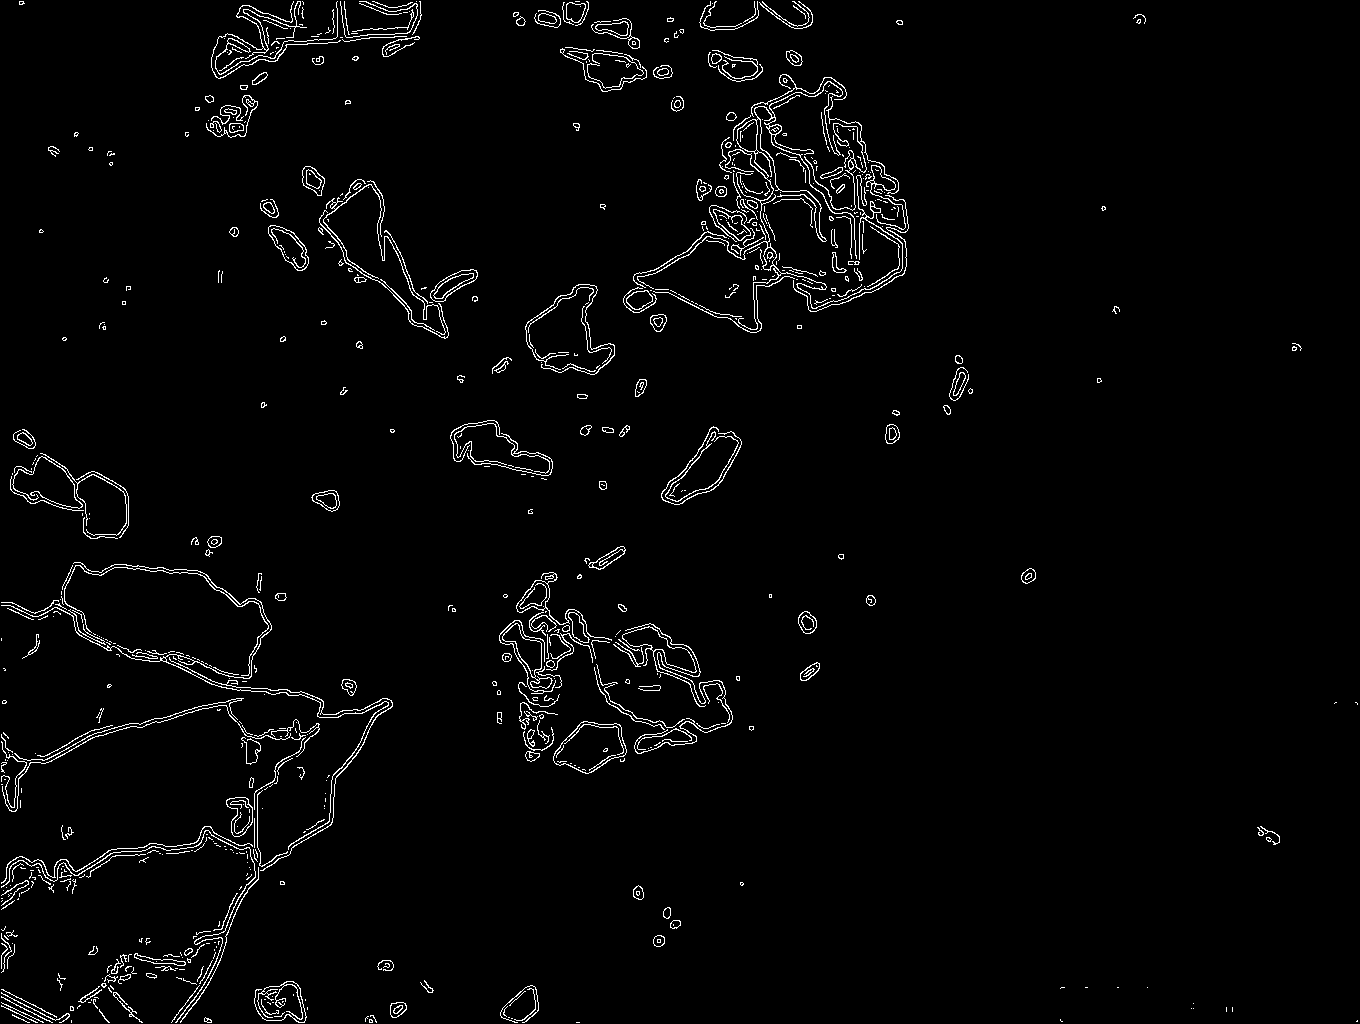

In [432]:
canny = skimage.feature.canny(dog, sigma=0, mask=~label_mask)
edges_image = Image.fromarray((canny * 255).astype(np.uint8))
edges_image

In [433]:
# canny = skimage.feature.canny(grayscale, sigma=0, mask=~label_mask) 
# edges_image = Image.fromarray((canny * 255).astype(np.uint8))
# edges_image

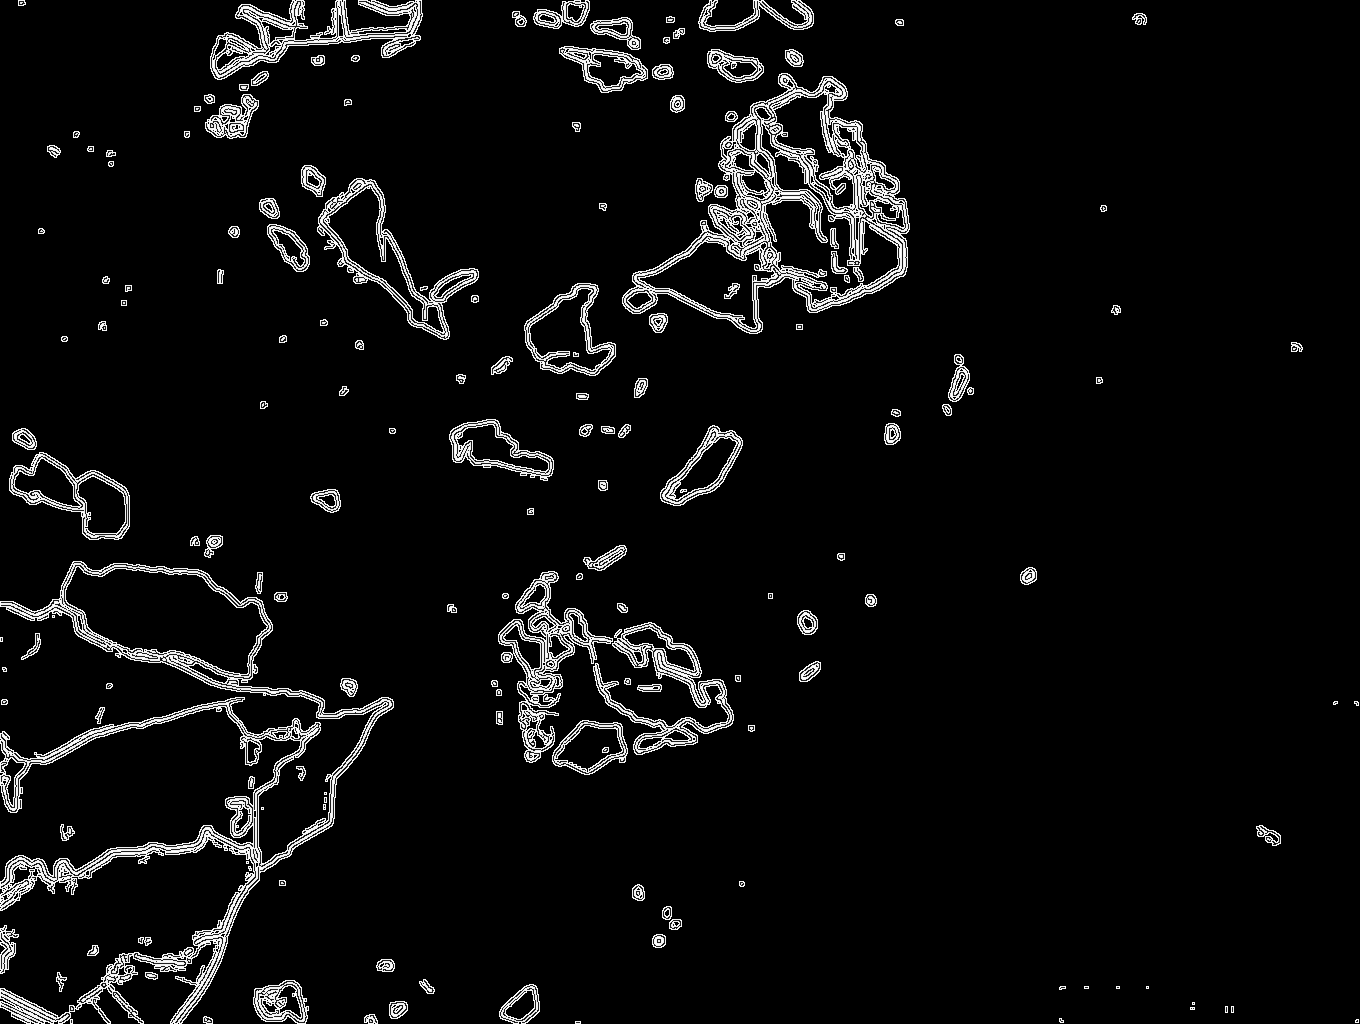

In [564]:
smoothing_sigma = 0.6 # Another knob to turn for the user.
more_dog = skimage.filters.difference_of_gaussians(canny, 0.5, smoothing_sigma)
dog_image = Image.fromarray((more_dog * 255).astype(np.uint8))
dog_image

In [ ]:
for axis in range(0, 1 + 1):
    _ = np.copy(more_dog)
    _ = np.insert(_, 0, np.ones(more_dog.shape[axis-1]), axis=axis)
    _ = np.insert(_, -1, [np.ones(more_dog.shape[axis-1])], axis=axis)
    if axis == 0:
        filled_holes = scipy.ndimage.binary_fill_holes(_)
        filled_holes = filled_holes[0:-1]
    # else:
    #     filled_holes = scipy.ndimage.binary_fill_holes(filled_holes)
    #     filled_holes = filled_holes[0:-1,0:-1]

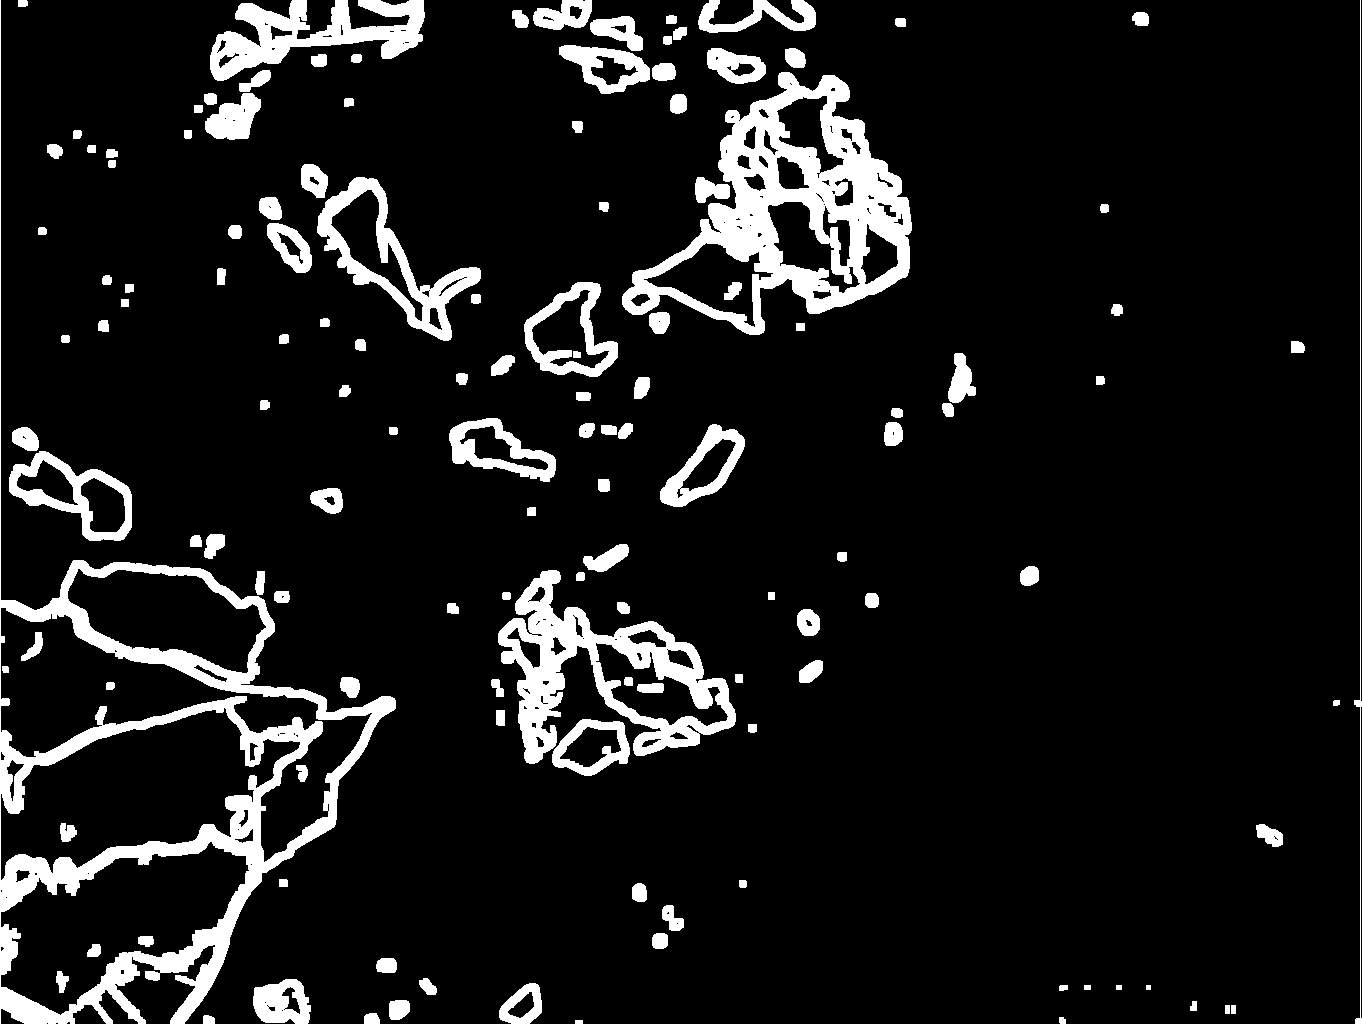

In [566]:
filled_holes_image = Image.fromarray(_.astype(bool))
filled_holes_image

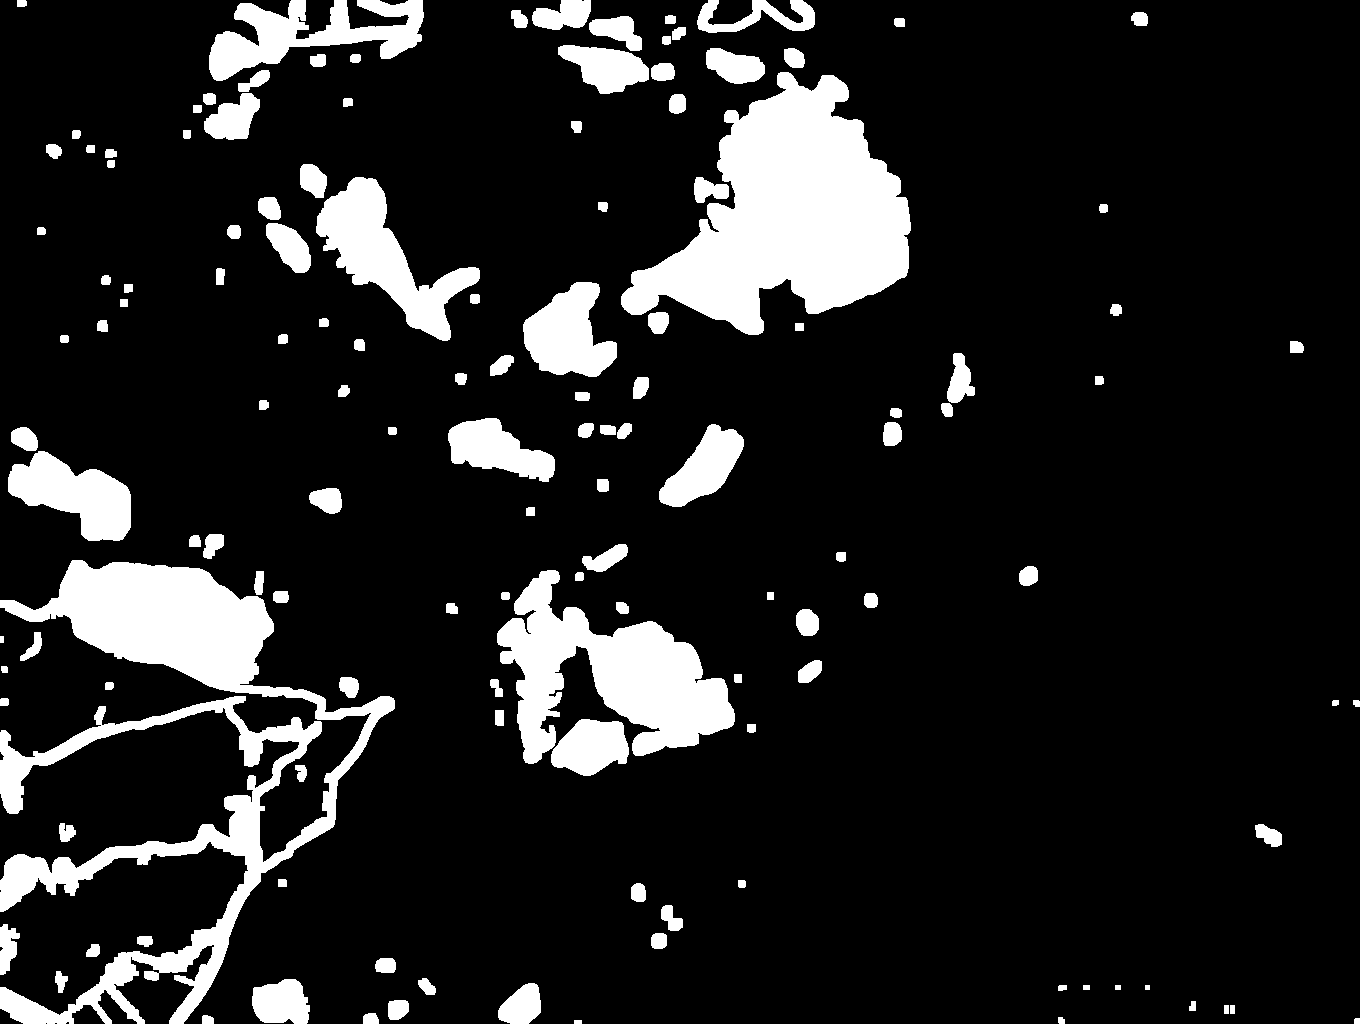

In [451]:
filled_holes = scipy.ndimage.binary_fill_holes(more_dog)
filled_holes_image = Image.fromarray(filled_holes)
filled_holes_image

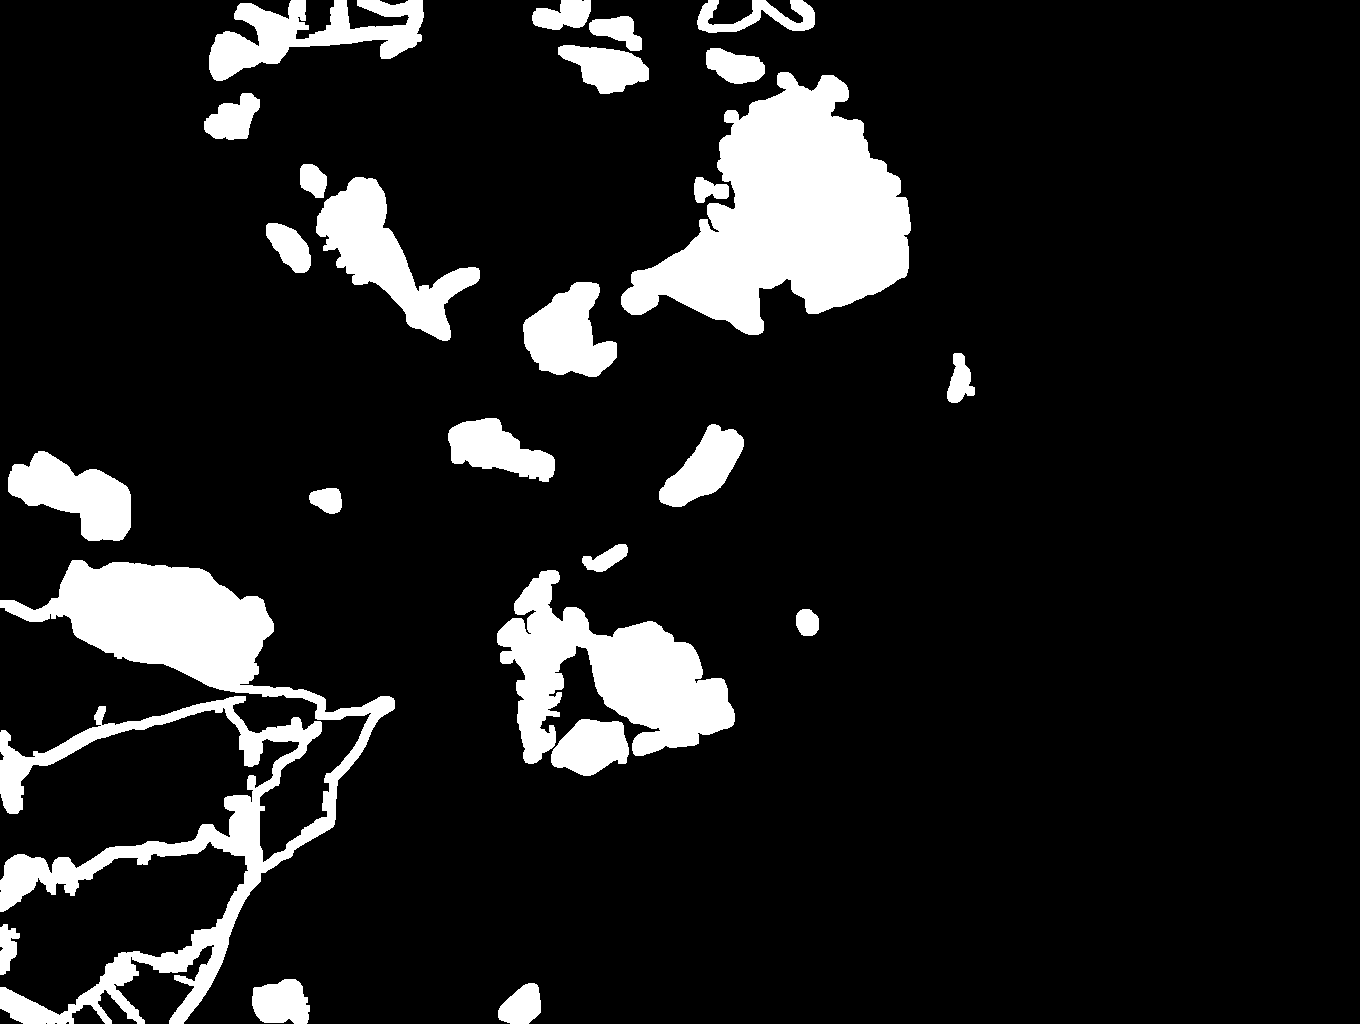

In [436]:
candidates_mask = skimage.morphology.remove_small_objects(filled_holes.astype(bool), 500)
candidates_image = Image.fromarray(candidates_mask)
candidates_image

In [437]:
random_image_array[~candidates_mask] = [0,0,0]

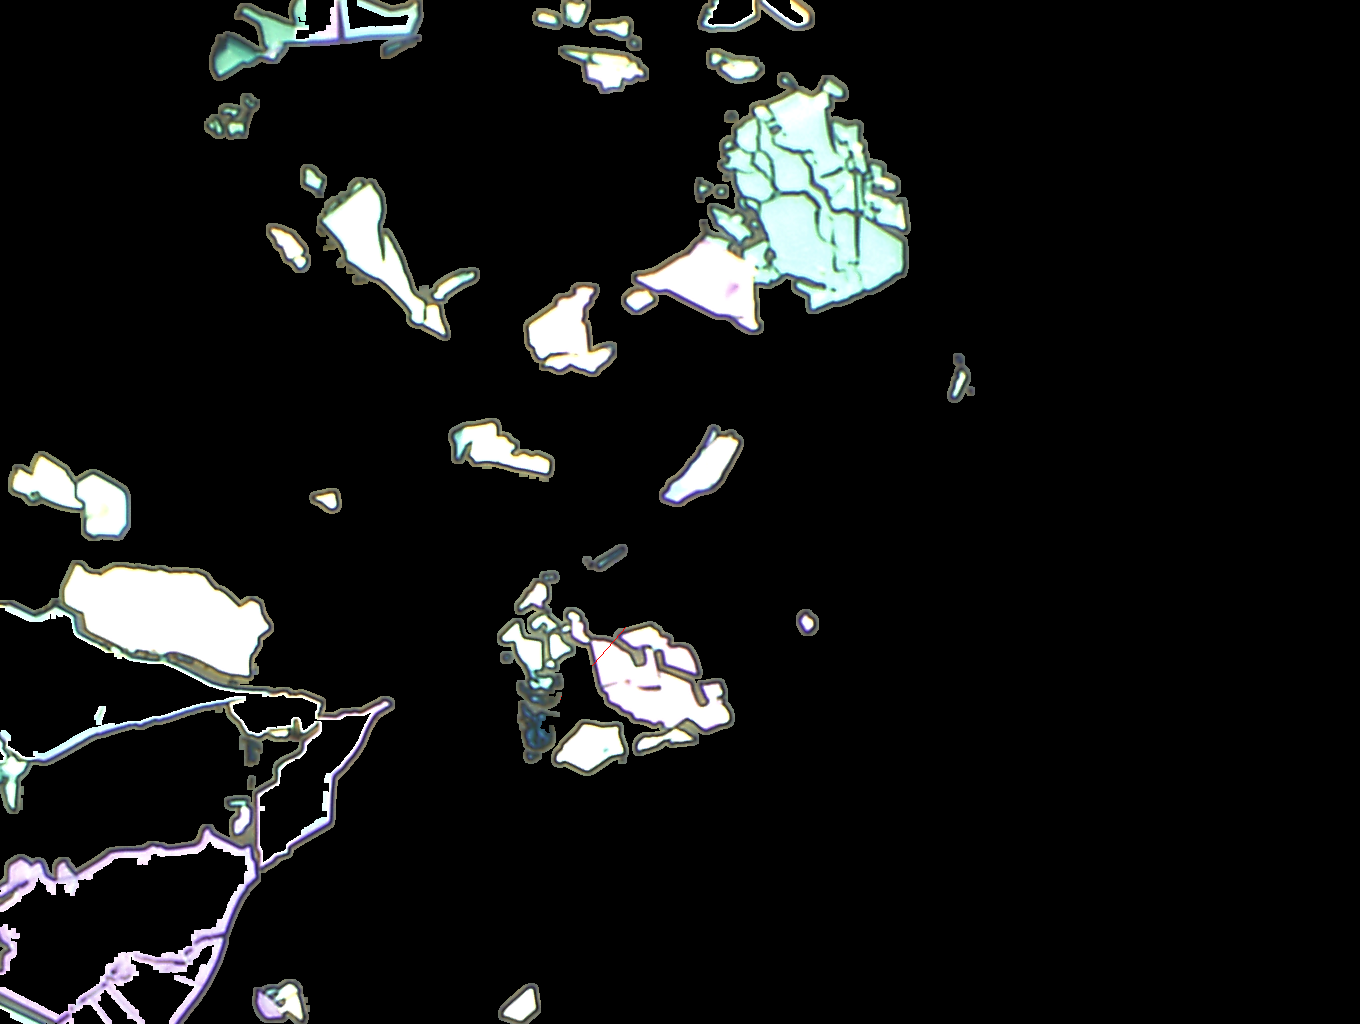

In [438]:
final_image = Image.fromarray(random_image_array)
final_image